# Dataset import

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('diamonds.csv', index_col=0) #Oss: Colonna 0 è carat

df.rename(columns={'depth': 'depth_p'}, inplace=True)
df.rename(columns={'table': 'table_p'}, inplace=True)

#Shuffle iniziale -  serve algoritmi stocastici anche prima di ogni epoca
df = df.sample(frac=1).reset_index(drop=True)

#Variabili ordinali - One Hot Encoding
cut_mapping = {
    'Fair': 1, 
    'Good': 2, 
    'Very Good': 3, 
    'Premium': 4, 
    'Ideal': 5
}

# Mappa per 'color' (Colore: J=1, D=7)
# D è il migliore (più incolore), J è il peggiore.
color_mapping = {
    'J': 1, 
    'I': 2, 
    'H': 3, 
    'G': 4, 
    'F': 5, 
    'E': 6, 
    'D': 7
}

# Mappa per 'clarity' (Purezza: I1=1, IF=8)
# IF è il migliore (Internally Flawless), I1 è il peggiore.
clarity_mapping = {
    'I1': 1, 
    'SI2': 2, 
    'SI1': 3, 
    'VS2': 4, 
    'VS1': 5, 
    'VVS2': 6, 
    'VVS1': 7, 
    'IF': 8
}

df['cut'] = df['cut'].map(cut_mapping)
df['color'] = df['color'].map(color_mapping)
df['clarity'] = df['clarity'].map(clarity_mapping)

print(df)
#### Per controllare se ci sono NaN
print(df.isna().sum())



       carat  cut  color  clarity  depth_p  table_p  price     x     y     z
0       0.71    5      4        6     61.7     57.0   3307  5.72  5.74  3.53
1       0.90    2      6        4     64.0     58.0   4203  6.07  6.02  3.87
2       0.40    5      4        7     62.3     54.0   1043  4.75  4.76  2.96
3       1.12    4      1        2     60.7     61.0   3266  6.71  6.64  4.05
4       0.54    4      4        4     61.0     60.0   1637  5.24  5.18  3.18
...      ...  ...    ...      ...      ...      ...    ...   ...   ...   ...
53935   0.35    5      6        5     61.2     56.0    829  4.53  4.55  2.78
53936   0.31    4      3        6     62.6     60.0    625  4.29  4.33  2.70
53937   0.54    5      2        3     62.3     55.0   1586  5.22  5.27  3.27
53938   1.09    3      4        5     60.0     57.0   7281  6.68  6.71  4.02
53939   0.80    4      1        3     58.4     59.0   2016  6.12  6.04  3.55

[53940 rows x 10 columns]
carat      0
cut        0
color      0
clarity   

# Removing Outliers


In [16]:
#### Rimozione Outliers
def detect_outlier(x):
    """
    Restituisce una maschera booleana (Series):
    True se il valore è un outlier, False altrimenti.
    """
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)
    IQR = Q3 - Q1
    
    # Condizione per outlier: sotto il minimo o sopra il massimo
    lower_bound = Q1 - (IQR * 1.5)
    upper_bound = Q3 + (IQR * 1.5)
    
    return (x > upper_bound) | (x < lower_bound)

def remove_outlier(df, columns=None):
    """
    Rimuove le righe che contengono outlier nelle colonne specificate.
    """
    if columns is None:
        columns = df.columns

    # Lavoriamo su una copia per evitare SettingWithCopyWarning
    df_cleaned = df.copy()

    for col in columns:
        # Troviamo gli outlier per la colonna corrente
        outliers_mask = detect_outlier(df_cleaned[col])
        
        # Filtriamo: teniamo solo le righe che NON (~) sono outlier
        # Il simbolo '~' in pandas equivale al '!' in R
        df_cleaned = df_cleaned[~outliers_mask]
        
    print("Outliers rimossi")
    df_cleaned = df_cleaned.reset_index(drop=True)
    print(f"Nuova dimensione: {df_cleaned.shape}")
    return df_cleaned

#Rimuovo outliers dei regressori numerici
cols_to_check = ['carat', 'depth_p', 'table_p', 'price', 'x', 'y', 'z']
df = remove_outlier(df, cols_to_check)
print(df)


Outliers rimossi
Nuova dimensione: (46532, 10)
       carat  cut  color  clarity  depth_p  table_p  price     x     y     z
0       0.71    5      4        6     61.7     57.0   3307  5.72  5.74  3.53
1       0.90    2      6        4     64.0     58.0   4203  6.07  6.02  3.87
2       0.40    5      4        7     62.3     54.0   1043  4.75  4.76  2.96
3       1.12    4      1        2     60.7     61.0   3266  6.71  6.64  4.05
4       0.54    4      4        4     61.0     60.0   1637  5.24  5.18  3.18
...      ...  ...    ...      ...      ...      ...    ...   ...   ...   ...
46527   1.26    4      2        4     61.2     59.0   6350  7.03  6.90  4.26
46528   0.35    5      6        5     61.2     56.0    829  4.53  4.55  2.78
46529   0.31    4      3        6     62.6     60.0    625  4.29  4.33  2.70
46530   0.54    5      2        3     62.3     55.0   1586  5.22  5.27  3.27
46531   1.09    3      4        5     60.0     57.0   7281  6.68  6.71  4.02

[46532 rows x 10 columns]


# Visualizing Data

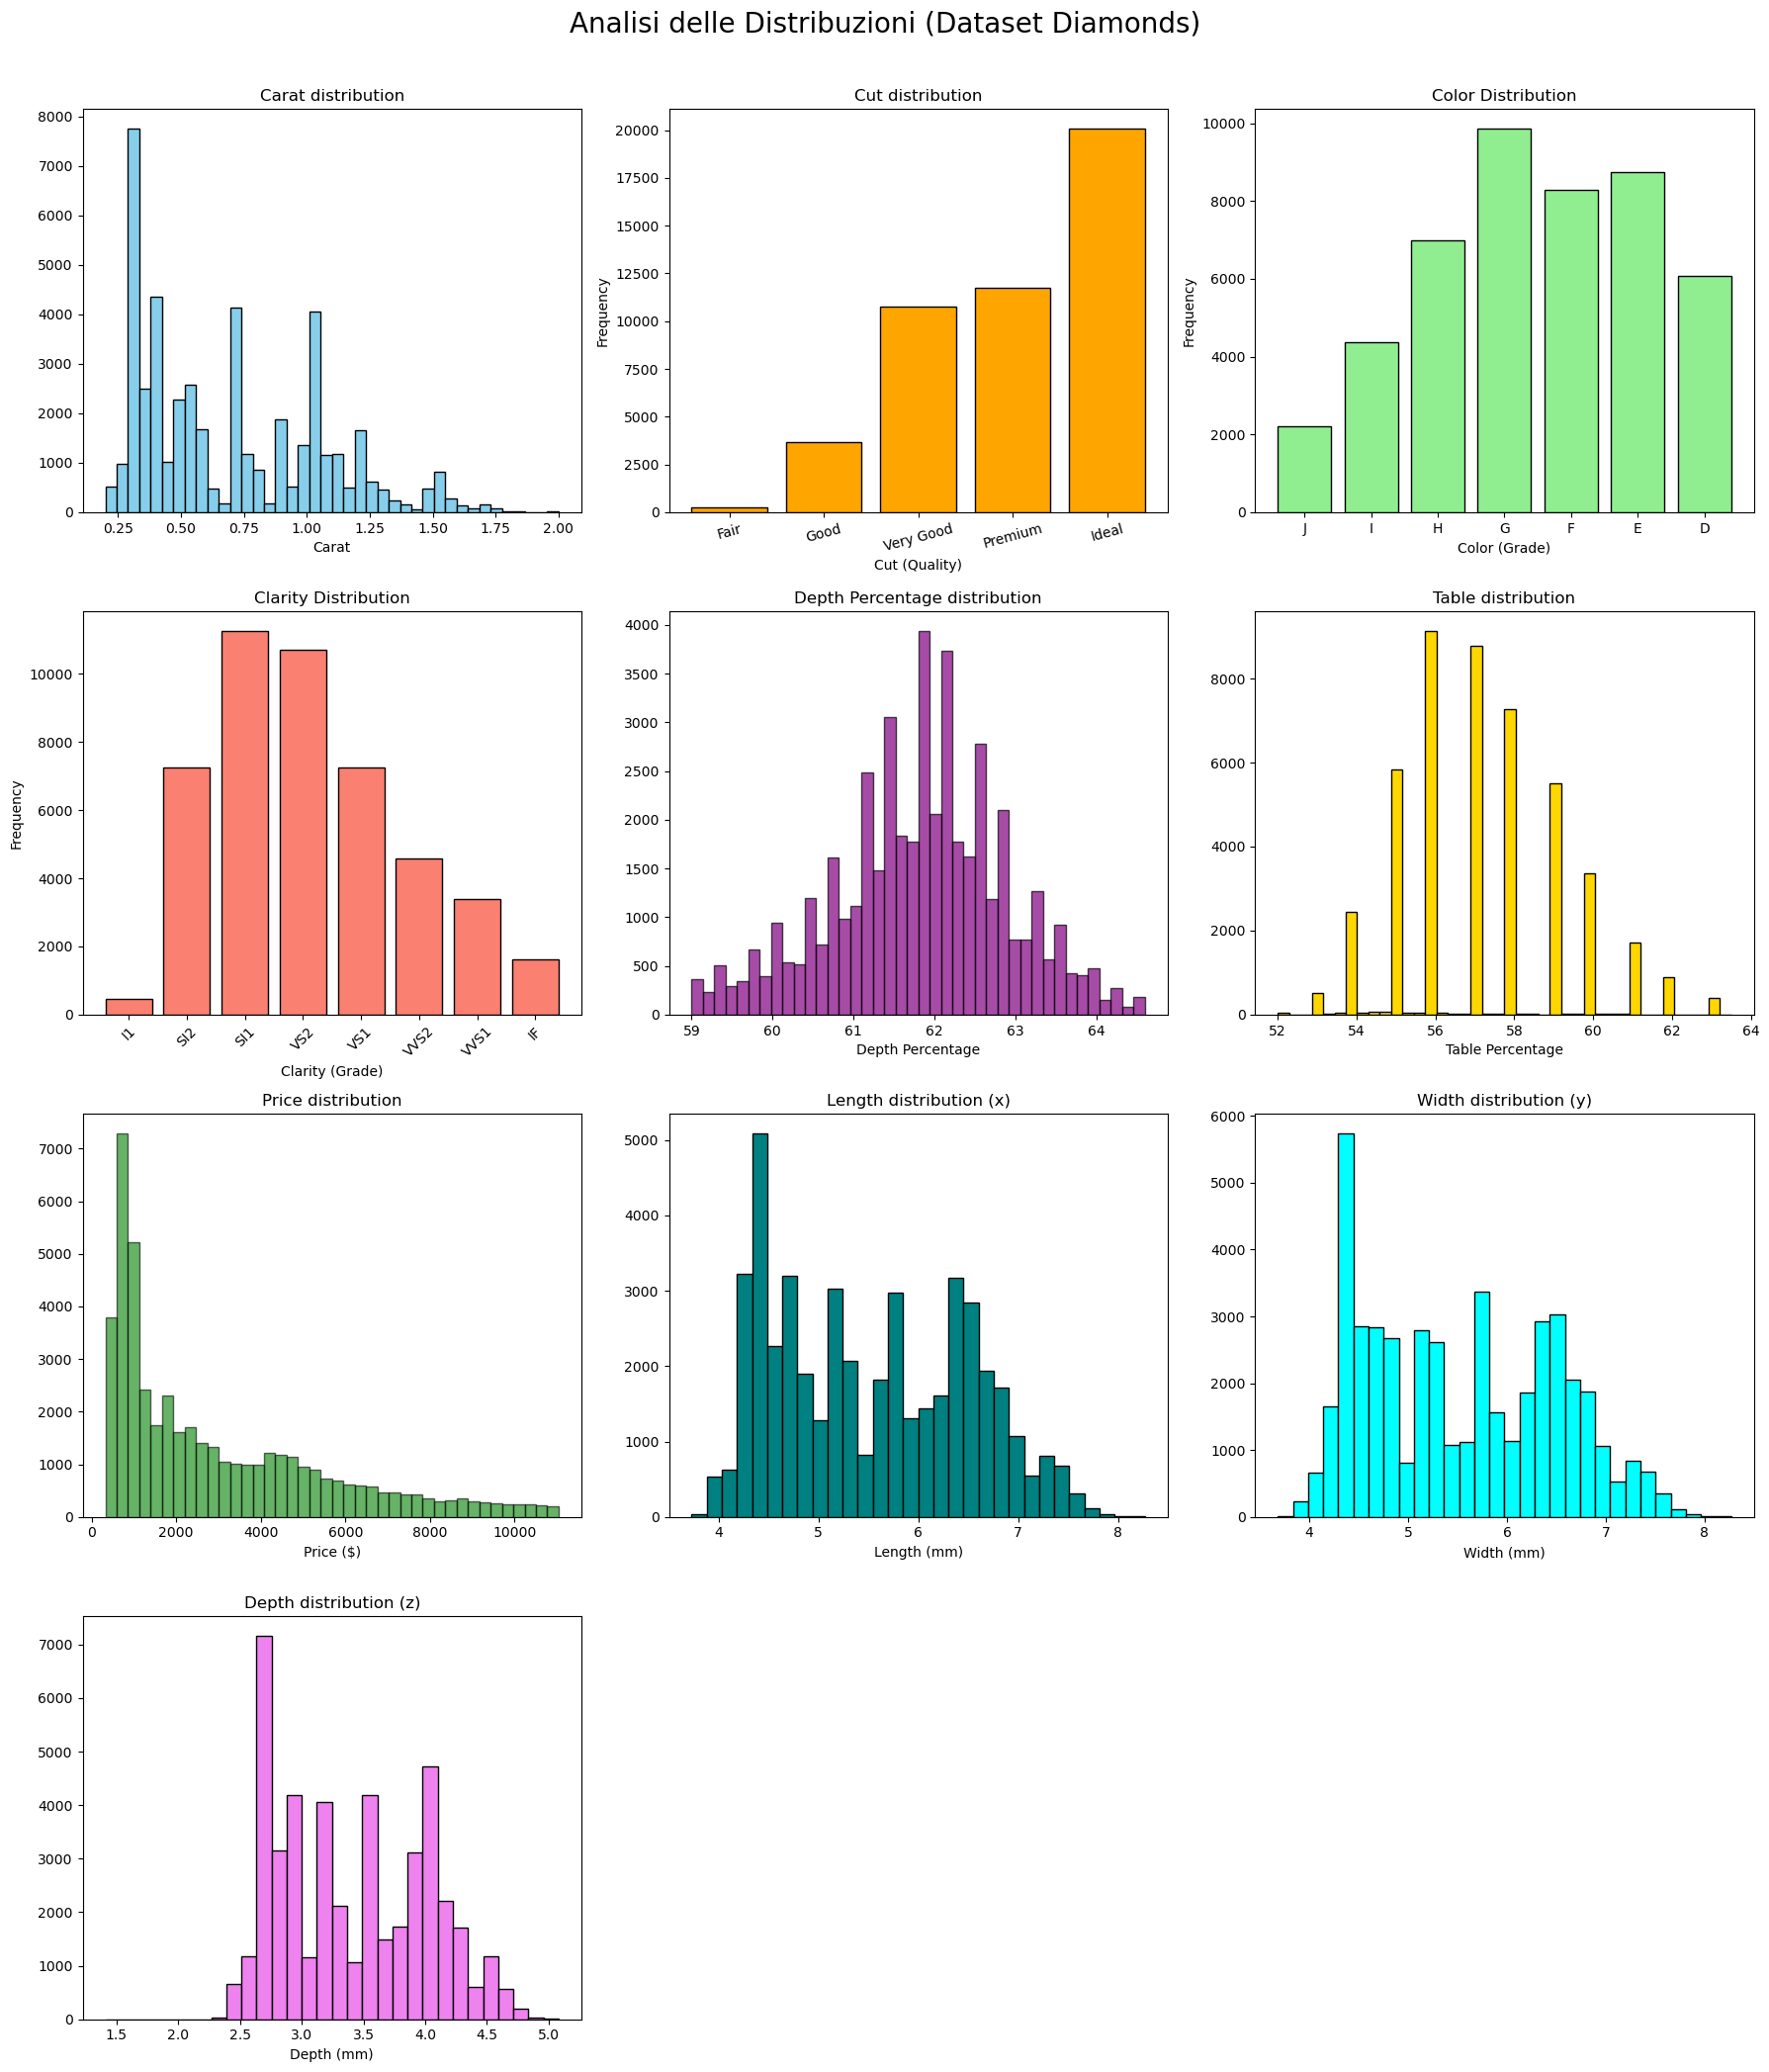

In [18]:
# --- DEFINIZIONE ETICHETTE ORIGINALI ---
cut_labels = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_labels = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_labels = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

# --- SETUP GRAFICO ---
fig, axes = plt.subplots(4, 3, figsize=(18, 22)) # Aumentato leggermente l'altezza
fig.suptitle('Analisi delle Distribuzioni (Dataset Diamonds)', fontsize=20)
ax = axes.flatten()

# --- 1. Carat (Istogramma) ---
ax[0].hist(df['carat'], bins=40, color='skyblue', edgecolor='black')
ax[0].set_title('Carat distribution')
ax[0].set_xlabel('Carat')

# --- 2. Cut (Barplot con Nomi) ---
cut_counts = df['cut'].value_counts().sort_index()
ax[1].bar(cut_counts.index, cut_counts.values, color='orange', edgecolor='black')
ax[1].set_title('Cut distribution')
ax[1].set_xlabel('Cut (Quality)')
ax[1].set_ylabel('Frequency')
# Sostituzione numeri con nomi
ax[1].set_xticks(cut_counts.index) # Posiziona i tick sui numeri (1,2,3,4,5)
ax[1].set_xticklabels(cut_labels, rotation=15) # Sostituisce con le stringhe

# --- 3. Color (Barplot con Nomi) ---
color_counts = df['color'].value_counts().sort_index()
ax[2].bar(color_counts.index, color_counts.values, color='lightgreen', edgecolor='black')
ax[2].set_title('Color Distribution')
ax[2].set_xlabel('Color (Grade)')
ax[2].set_ylabel('Frequency')
# Sostituzione numeri con nomi
ax[2].set_xticks(color_counts.index)
ax[2].set_xticklabels(color_labels)

# --- 4. Clarity (Barplot con Nomi) ---
clarity_counts = df['clarity'].value_counts().sort_index()
ax[3].bar(clarity_counts.index, clarity_counts.values, color='salmon', edgecolor='black')
ax[3].set_title('Clarity Distribution')
ax[3].set_xlabel('Clarity (Grade)')
ax[3].set_ylabel('Frequency')
# Sostituzione numeri con nomi
ax[3].set_xticks(clarity_counts.index)
ax[3].set_xticklabels(clarity_labels, rotation=45) # Ruotiamo perché sono tanti

# --- 5. Depth Percentage ---
ax[4].hist(df['depth_p'], bins=40, color='purple', alpha=0.7, edgecolor='black')
ax[4].set_title('Depth Percentage distribution')
ax[4].set_xlabel('Depth Percentage')

# --- 6. Table Percentage ---
ax[5].hist(df['table_p'], bins=40, color='gold', edgecolor='black')
ax[5].set_title('Table distribution')
ax[5].set_xlabel('Table Percentage')

# --- 7. Price ---
ax[6].hist(df['price'], bins=40, color='green', alpha=0.6, edgecolor='black')
ax[6].set_title('Price distribution')
ax[6].set_xlabel('Price ($)')

# --- 8. Length (x) ---
ax[7].hist(df['x'], bins=30, color='teal', edgecolor='black')
ax[7].set_title('Length distribution (x)')
ax[7].set_xlabel('Length (mm)')

# --- 9. Width (y) ---
ax[8].hist(df['y'], bins=30, color='cyan', edgecolor='black')
ax[8].set_title('Width distribution (y)')
ax[8].set_xlabel('Width (mm)')

# --- 10. Depth mm (z) ---
ax[9].hist(df['z'], bins=30, color='violet', edgecolor='black')
ax[9].set_title('Depth distribution (z)')
ax[9].set_xlabel('Depth (mm)')

# --- Pulizia ---
ax[10].axis('off')
ax[11].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.97]) 
plt.show()

# Mean e Std dataset variable

In [ ]:
#Estrema variabilità
print(df.describe().T)

#Necessario standardizzare per permettere a GD di lavorare meglio

           count         mean          std     min     25%      50%      75%  \
carat    46532.0     0.697966     0.362025    0.20    0.37     0.59     1.01   
cut      46532.0     4.025724     1.014818    1.00    3.00     4.00     5.00   
color    46532.0     4.464820     1.685251    1.00    3.00     4.00     6.00   
clarity  46532.0     4.126773     1.643282    1.00    3.00     4.00     5.00   
depth_p  46532.0    61.804302     1.077341   59.00   61.20    61.90    62.50   
table_p  46532.0    57.238621     2.013841   52.00   56.00    57.00    59.00   
price    46532.0  2999.000107  2598.654394  326.00  880.00  2002.50  4523.00   
x        46532.0     5.521339     0.964476    3.73    4.62     5.39     6.39   
y        46532.0     5.526371     0.958648    3.68    4.63     5.40     6.39   
z        46532.0     3.413855     0.597215    1.41    2.85     3.33     3.96   

              max  
carat        2.00  
cut          5.00  
color        7.00  
clarity      8.00  
depth_p     64.60  

# Standardization and preparing dataset

In [34]:
from sklearn.preprocessing import StandardScaler

#Funzione di standardizzazione manuale per vettori 1-D
def standardize(x):
  """Standardize vector 1-D"""
  mean_val = np.mean(x)
  std_val = np.std(x)
  x_scaled = (x - mean_val) / std_val
  return x_scaled

#Funzione per costruire le matrici
def build_model_data(regr, obj):
  """Creating data in Matrix Form"""
  num_samples = len(obj)
    
  # Aggiunge colonna di 1 (Bias)
  X = np.c_[np.ones(num_samples), regr]
    
  # Trasforma y da (n,) a (n, 1)
  y = obj.reshape(-1, 1)
    
  return X, y


# Estrazione dati
regressors = df.drop('price', axis=1).values
objective = df['price'].values

# Standardizzazione Feature (X) con Sklearn
scaler = StandardScaler()
regr_scal = scaler.fit_transform(regressors)

# Standardizzazione Target (y) manuale
# Nota: va bene usare la tua funzione qui perché 'objective' è 1D
obj_scal = standardize(objective)

# Costruzione finale
X, y = build_model_data(regr_scal, obj_scal)

# Verifica Dimensioni
print(f"X shape: {X.shape}")  # Deve essere (N, 10)
print(f"y shape: {y.shape}")  # Deve essere (N, 1) <-- Molto importante l'1 finale


X shape: (46532, 10)
y shape: (46532, 1)
